In [1]:
# Do NOT reinstall torch here, because it may overwrite your CUDA-enabled PyTorch.
%pip install -q kagglehub matplotlib tqdm pillow ipywidgets

import os
import math
import glob
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.utils as vutils
import matplotlib.pyplot as plt
from tqdm import tqdm
import kagglehub

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print("Torch:", torch.__version__)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Note: you may need to restart the kernel to use updated packages.
Using device: cuda
Torch: 2.11.0+cu128
GPU: NVIDIA RTX PRO 500 Blackwell Generation Laptop GPU


In [2]:
# Dataset path
path = r"C:\Users\OFEKAM\Downloads\archive"
print("Path to dataset files:", path)

image_dir = os.path.join(path, "img_align_celeba", "img_align_celeba")
if not os.path.exists(image_dir):
    image_dir = os.path.join(path, "img_align_celeba")

print(f"Targeting image directory: {image_dir}")


class RealCelebASRDataset(Dataset):
    def __init__(self, image_dir, hr_size=64, max_samples=64):
        self.image_paths = sorted(glob.glob(os.path.join(image_dir, "*.jpg")))

        if len(self.image_paths) == 0:
            raise FileNotFoundError(
                f"No .jpg images found in {image_dir}. Check the directory path."
            )

        if max_samples and max_samples < len(self.image_paths):
            self.image_paths = self.image_paths[:max_samples]

        print(f"Successfully indexed {len(self.image_paths)} real images for training.")

        self.hr_transform = transforms.Compose([
            # CelebA images are not square. CenterCrop prevents face distortion.
            transforms.CenterCrop(178),
            transforms.Resize((hr_size, hr_size)),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        img = Image.open(img_path).convert("RGB")
        hr_img = self.hr_transform(img)
        return {"HR": hr_img}


# First: overfit test on 64 images.
# If this works, later increase max_samples to 10000.
dataset = RealCelebASRDataset(
    image_dir=image_dir,
    hr_size=64,
    max_samples=64
)

data_loader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    drop_last=True
)

Path to dataset files: C:\Users\OFEKAM\Downloads\archive
Targeting image directory: C:\Users\OFEKAM\Downloads\archive\img_align_celeba\img_align_celeba
Successfully indexed 64 real images for training.


In [3]:
class PositionalEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2

        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)

        embeddings = time[:, None].float() * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)

        return embeddings


class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim, groups=8):
        super().__init__()

        self.time_mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_emb_dim, out_ch)
        )

        self.block1 = nn.Sequential(
            nn.GroupNorm(groups, in_ch),
            nn.SiLU(),
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)
        )

        self.block2 = nn.Sequential(
            nn.GroupNorm(groups, out_ch),
            nn.SiLU(),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)
        )

        if in_ch != out_ch:
            self.res_conv = nn.Conv2d(in_ch, out_ch, kernel_size=1)
        else:
            self.res_conv = nn.Identity()

    def forward(self, x, t_emb):
        h = self.block1(x)

        time_emb = self.time_mlp(t_emb)
        h = h + time_emb[:, :, None, None]

        h = self.block2(h)

        return h + self.res_conv(x)


class AttentionBlock(nn.Module):
    def __init__(self, channels, num_heads=4, groups=8):
        super().__init__()

        self.norm = nn.GroupNorm(groups, channels)
        self.attn = nn.MultiheadAttention(
            embed_dim=channels,
            num_heads=num_heads,
            batch_first=True
        )

    def forward(self, x):
        b, c, h, w = x.shape

        residual = x
        x = self.norm(x)

        # [B, C, H, W] -> [B, H*W, C]
        x = x.view(b, c, h * w).transpose(1, 2)

        x, _ = self.attn(x, x, x, need_weights=False)

        # [B, H*W, C] -> [B, C, H, W]
        x = x.transpose(1, 2).view(b, c, h, w)

        return x + residual


class Downsample(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Conv2d(
            channels,
            channels,
            kernel_size=3,
            stride=2,
            padding=1
        )

    def forward(self, x):
        return self.conv(x)


class Upsample(nn.Module):
    def __init__(self, channels):
        super().__init__()

        self.net = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        )

    def forward(self, x):
        return self.net(x)


class ConditionalUNet(nn.Module):
    def __init__(
        self,
        in_channels=6,
        out_channels=3,
        base_channels=64,
        time_emb_dim=128
    ):
        super().__init__()

        self.time_mlp = nn.Sequential(
            PositionalEmbedding(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim * 4),
            nn.SiLU(),
            nn.Linear(time_emb_dim * 4, time_emb_dim)
        )

        # 64x64
        self.init_conv = nn.Conv2d(
            in_channels,
            base_channels,
            kernel_size=3,
            padding=1
        )

        self.down1 = ResBlock(
            base_channels,
            base_channels,
            time_emb_dim
        )
        self.downsample1 = Downsample(base_channels)

        # 32x32
        self.down2 = ResBlock(
            base_channels,
            base_channels * 2,
            time_emb_dim
        )
        self.downsample2 = Downsample(base_channels * 2)

        # 16x16
        self.down3 = ResBlock(
            base_channels * 2,
            base_channels * 4,
            time_emb_dim
        )
        self.downsample3 = Downsample(base_channels * 4)

        # 8x8 bottleneck
        self.mid1 = ResBlock(
            base_channels * 4,
            base_channels * 4,
            time_emb_dim
        )
        self.attn = AttentionBlock(base_channels * 4)
        self.mid2 = ResBlock(
            base_channels * 4,
            base_channels * 4,
            time_emb_dim
        )

        # 8x8 -> 16x16
        self.upsample3 = Upsample(base_channels * 4)
        self.up3 = ResBlock(
            base_channels * 4 + base_channels * 4,
            base_channels * 2,
            time_emb_dim
        )

        # 16x16 -> 32x32
        self.upsample2 = Upsample(base_channels * 2)
        self.up2 = ResBlock(
            base_channels * 2 + base_channels * 2,
            base_channels,
            time_emb_dim
        )

        # 32x32 -> 64x64
        self.upsample1 = Upsample(base_channels)
        self.up1 = ResBlock(
            base_channels + base_channels,
            base_channels,
            time_emb_dim
        )

        self.final = nn.Sequential(
            nn.GroupNorm(8, base_channels),
            nn.SiLU(),
            nn.Conv2d(base_channels, out_channels, kernel_size=3, padding=1)
        )

    def forward(self, x, t):
        t_emb = self.time_mlp(t)

        # Encoder
        x0 = self.init_conv(x)              # 64x64, 64

        x1 = self.down1(x0, t_emb)          # 64x64, 64
        x = self.downsample1(x1)            # 32x32, 64

        x2 = self.down2(x, t_emb)           # 32x32, 128
        x = self.downsample2(x2)            # 16x16, 128

        x3 = self.down3(x, t_emb)           # 16x16, 256
        x = self.downsample3(x3)            # 8x8, 256

        # Bottleneck
        x = self.mid1(x, t_emb)
        x = self.attn(x)
        x = self.mid2(x, t_emb)

        # Decoder
        x = self.upsample3(x)               # 16x16, 256
        x = torch.cat([x, x3], dim=1)       # 16x16, 512
        x = self.up3(x, t_emb)              # 16x16, 128

        x = self.upsample2(x)               # 32x32, 128
        x = torch.cat([x, x2], dim=1)       # 32x32, 256
        x = self.up2(x, t_emb)              # 32x32, 64

        x = self.upsample1(x)               # 64x64, 64
        x = torch.cat([x, x1], dim=1)       # 64x64, 128
        x = self.up1(x, t_emb)              # 64x64, 64

        return self.final(x)

In [4]:
class SR3Diffusion(nn.Module):
    def __init__(self, denoise_fn, timesteps=500, loss_type="l1"):
        super().__init__()
        self.denoise_fn = denoise_fn
        self.timesteps = timesteps
        self.loss_type = loss_type

        beta = torch.linspace(1e-4, 0.02, timesteps, dtype=torch.float32)
        alpha = 1.0 - beta
        alpha_bar = torch.cumprod(alpha, dim=0)

        self.register_buffer("betas", beta)
        self.register_buffer("alphas", alpha)
        self.register_buffer("alphas_bar", alpha_bar)
        self.register_buffer("sqrt_alphas_bar", torch.sqrt(alpha_bar))
        self.register_buffer("sqrt_one_minus_alphas_bar", torch.sqrt(1.0 - alpha_bar))
        self.register_buffer("sqrt_recip_alphas", torch.sqrt(1.0 / alpha))

    def q_sample(self, x_hr, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x_hr)

        sqrt_alpha_bar_t = self.sqrt_alphas_bar[t].view(-1, 1, 1, 1)
        sqrt_one_minus_alpha_bar_t = self.sqrt_one_minus_alphas_bar[t].view(-1, 1, 1, 1)

        return sqrt_alpha_bar_t * x_hr + sqrt_one_minus_alpha_bar_t * noise

    def forward(self, x_hr, x_lr, t):
        noise = torch.randn_like(x_hr)
        x_noisy = self.q_sample(x_hr=x_hr, t=t, noise=noise)

        x_lr_upscaled = F.interpolate(
            x_lr,
            size=x_hr.shape[-2:],
            mode="bicubic",
            align_corners=False
        )

        model_input = torch.cat([x_noisy, x_lr_upscaled], dim=1)
        predicted_noise = self.denoise_fn(model_input, t)

        if self.loss_type == "l1":
            return F.l1_loss(predicted_noise, noise)
        else:
            return F.mse_loss(predicted_noise, noise)

    @torch.no_grad()
    def p_sample_loop(self, x_lr):
        self.eval()

        device = x_lr.device
        batch_size = x_lr.shape[0]
        hr_shape = (batch_size, 3, x_lr.shape[2] * 4, x_lr.shape[3] * 4)

        img = torch.randn(hr_shape, device=device)

        x_lr_upscaled = F.interpolate(
            x_lr,
            size=hr_shape[-2:],
            mode="bicubic",
            align_corners=False
        )

        for i in tqdm(
            reversed(range(self.timesteps)),
            desc="Refinement Steps",
            total=self.timesteps
        ):
            t = torch.full(
                (batch_size,),
                i,
                device=device,
                dtype=torch.long
            )

            model_input = torch.cat([img, x_lr_upscaled], dim=1)
            pred_noise = self.denoise_fn(model_input, t)

            beta_t = self.betas[t].view(-1, 1, 1, 1)
            sqrt_one_minus_alpha_bar_t = self.sqrt_one_minus_alphas_bar[t].view(-1, 1, 1, 1)
            sqrt_recip_alpha_t = self.sqrt_recip_alphas[t].view(-1, 1, 1, 1)

            mean = sqrt_recip_alpha_t * (
                img - (beta_t / sqrt_one_minus_alpha_bar_t) * pred_noise
            )

            if i > 0:
                noise = torch.randn_like(img)
                sigma_t = torch.sqrt(beta_t)
                img = mean + sigma_t * noise
            else:
                img = mean

        return img.clamp(-1, 1)

In [5]:
print("Testing DataLoader...")

import time
start = time.time()

batch = next(iter(data_loader))

print("First batch loaded in:", time.time() - start, "seconds")
print("Batch keys:", batch.keys())
print("HR shape:", batch["HR"].shape)
print("HR device before CUDA:", batch["HR"].device)

x_hr = batch["HR"].to(device, non_blocking=True)
print("HR device after CUDA:", x_hr.device)

print("CUDA allocated:", torch.cuda.memory_allocated() / 1024**2, "MB")
print("CUDA reserved:", torch.cuda.memory_reserved() / 1024**2, "MB")

Testing DataLoader...
First batch loaded in: 0.7481439113616943 seconds
Batch keys: dict_keys(['HR'])
HR shape: torch.Size([16, 3, 64, 64])
HR device before CUDA: cpu
HR device after CUDA: cuda:0
CUDA allocated: 0.75 MB
CUDA reserved: 2.0 MB


In [6]:
# Hyperparameters for overfit test
EPOCHS = 400
TIMESTEPS = 500
LR = 2e-4
LR_SIZE = 16

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if device.type == "cuda":
    torch.backends.cudnn.benchmark = True

scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))

unet = ConditionalUNet(
    in_channels=6,
    out_channels=3,
    base_channels=64,
    time_emb_dim=128
).to(device)

sr3 = SR3Diffusion(
    denoise_fn=unet,
    timesteps=TIMESTEPS,
    loss_type="mse"
).to(device)

optimizer = torch.optim.Adam(sr3.parameters(), lr=LR)

print("Starting SR3 overfit test...")
print("Device:", device)
print("Model device:", next(sr3.parameters()).device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    torch.cuda.empty_cache()

loss_history = []

for epoch in range(1, EPOCHS + 1):
    sr3.train()
    epoch_loss = 0.0

    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch}/{EPOCHS}")

    for step, batch in enumerate(progress_bar):
        optimizer.zero_grad(set_to_none=True)

        x_hr = batch["HR"].to(device, non_blocking=True)

        x_lr = F.interpolate(
            x_hr,
            size=(LR_SIZE, LR_SIZE),
            mode="bicubic",
            align_corners=False
        )

        if epoch == 1 and step == 0:
            print("x_hr device:", x_hr.device)
            print("x_lr device:", x_lr.device)
            print("Model device:", next(sr3.parameters()).device)
            print("x_hr shape:", x_hr.shape)
            print("x_lr shape:", x_lr.shape)

        t = torch.randint(
            0,
            TIMESTEPS,
            (x_hr.shape[0],),
            device=device,
            dtype=torch.long
        )

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=(device.type == "cuda")
        ):
            loss = sr3(x_hr, x_lr, t)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        loss_value = loss.detach().item()
        epoch_loss += loss_value

        if step % 10 == 0:
            progress_bar.set_postfix({"Loss": f"{loss_value:.4f}"})

        if epoch == 1 and step == 0 and device.type == "cuda":
            print("Allocated after first batch:", torch.cuda.memory_allocated() / 1024**2, "MB")
            print("Reserved after first batch:", torch.cuda.memory_reserved() / 1024**2, "MB")

    avg_loss = epoch_loss / len(data_loader)
    loss_history.append(avg_loss)

    print(f"Epoch {epoch} finished. Avg Loss: {avg_loss:.4f}")

Starting SR3 overfit test...
Device: cuda
Model device: cuda:0
GPU: NVIDIA RTX PRO 500 Blackwell Generation Laptop GPU


Epoch 1/400:   0%|          | 0/4 [00:00<?, ?it/s]

x_hr device: cuda:0
x_lr device: cuda:0
Model device: cuda:0
x_hr shape: torch.Size([16, 3, 64, 64])
x_lr shape: torch.Size([16, 3, 16, 16])


Epoch 1/400:  50%|█████     | 2/4 [00:11<00:09,  4.87s/it, Loss=1.0696]

Allocated after first batch: 125.87060546875 MB
Reserved after first batch: 174.0 MB


...

Epoch 398 finished. Avg Loss: 0.0222


Epoch 399/400: 100%|██████████| 4/4 [00:00<00:00, 14.25it/s, Loss=0.0405]


Epoch 399 finished. Avg Loss: 0.0293


Epoch 400/400: 100%|██████████| 4/4 [00:00<00:00, 15.26it/s, Loss=0.0296]

Epoch 400 finished. Avg Loss: 0.0166


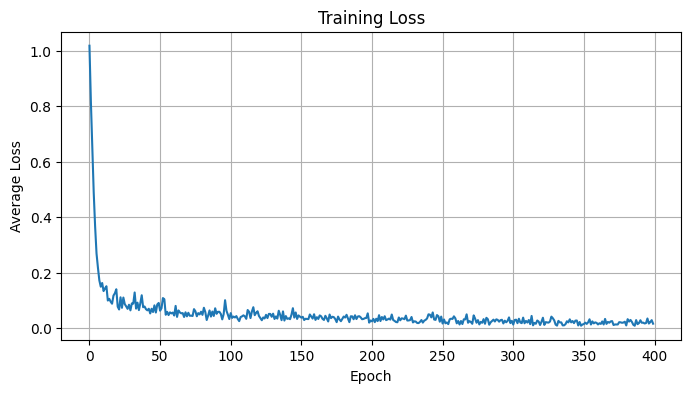

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()

### Save the Trained Model

After training, it's crucial to save the model's state dictionary. This allows you to reload the trained model later without having to retrain it, which is especially useful for long training processes.

In [8]:
model_save_path = "sr3_overfit_64_samples.pth"

torch.save(sr3.state_dict(), model_save_path)

print(f"Trained model saved to: {model_save_path}")

Trained model saved to: sr3_overfit_64_samples.pth


Generating 4x Super-Resolution faces via Repeated Refinement...


Refinement Steps: 100%|██████████| 500/500 [00:03<00:00, 153.86it/s]


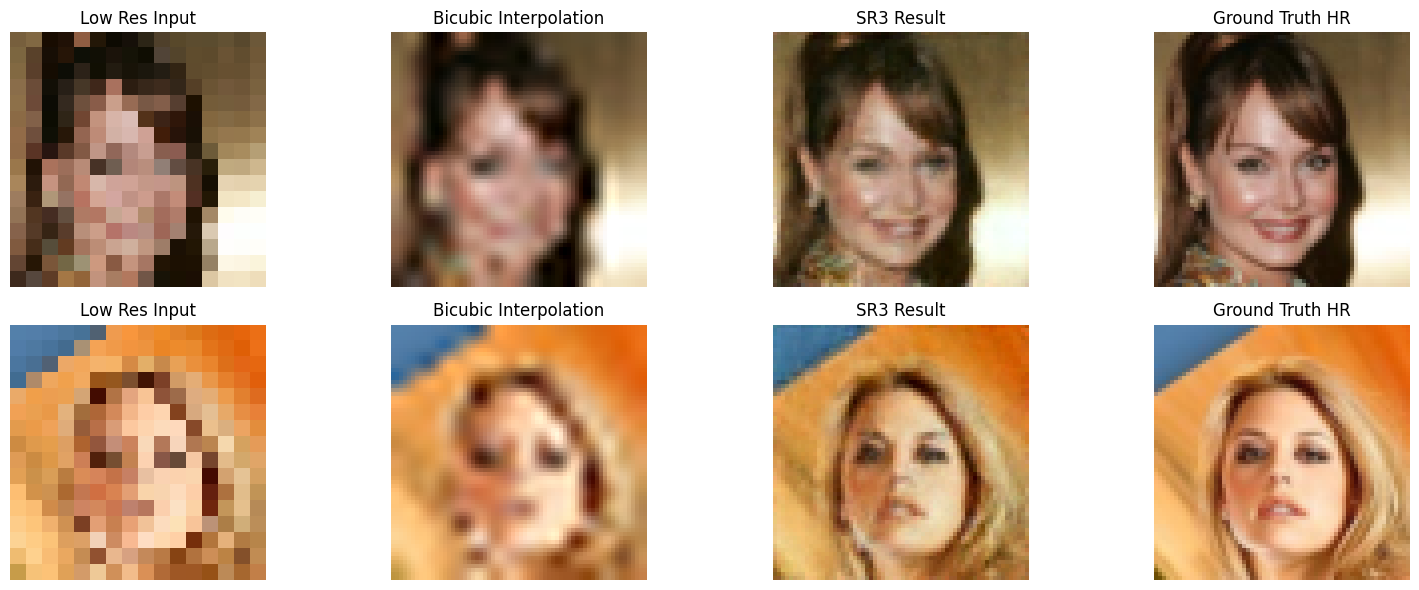

In [10]:
# Evaluate model
sr3.eval()

sample_batch = next(iter(data_loader))

x_hr_sample = sample_batch["HR"][:2].to(device, non_blocking=True)

x_lr_sample = F.interpolate(
    x_hr_sample,
    size=(LR_SIZE, LR_SIZE),
    mode="bicubic",
    align_corners=False
)

print("Generating 4x Super-Resolution faces via Repeated Refinement...")

# For sampling, avoid autocast first. Full precision is more stable.
with torch.no_grad():
    generated_hr = sr3.p_sample_loop(x_lr_sample)

generated_hr = generated_hr.clamp(-1, 1)

def denorm(tensor):
    return torch.clamp((tensor + 1.0) / 2.0, 0.0, 1.0)

bicubic_baseline = F.interpolate(
    x_lr_sample,
    size=x_hr_sample.shape[-2:],
    mode="bicubic",
    align_corners=False
)

x_lr_plot = denorm(x_lr_sample).detach().float().cpu()
bicubic_plot = denorm(bicubic_baseline).detach().float().cpu()
generated_plot = denorm(generated_hr).detach().float().cpu()
x_hr_plot = denorm(x_hr_sample).detach().float().cpu()

num_samples = min(2, x_hr_plot.shape[0])

fig, axes = plt.subplots(num_samples, 4, figsize=(16, 6))

if num_samples == 1:
    axes = axes[None, :]

labels = [
    "Low Res Input",
    "Bicubic Interpolation",
    "SR3 Result",
    "Ground Truth HR"
]

for i in range(num_samples):
    axes[i, 0].imshow(x_lr_plot[i].permute(1, 2, 0))
    axes[i, 0].set_title(labels[0])
    axes[i, 0].axis("off")

    axes[i, 1].imshow(bicubic_plot[i].permute(1, 2, 0))
    axes[i, 1].set_title(labels[1])
    axes[i, 1].axis("off")

    axes[i, 2].imshow(generated_plot[i].permute(1, 2, 0))
    axes[i, 2].set_title(labels[2])
    axes[i, 2].axis("off")

    axes[i, 3].imshow(x_hr_plot[i].permute(1, 2, 0))
    axes[i, 3].set_title(labels[3])
    axes[i, 3].axis("off")

plt.tight_layout()
plt.show()